# Thermal Features vs. Breaking Load — Step-by-Step Analysis

**Goal:** Identify which thermal features extracted from IR imaging are physically meaningful predictors of the specimen breaking load (`peso_rottura_kg`), and whether they mediate the effect of pause duration (`pausa_s`).

## Feature classification
- **FEAT_DIRECT** (blue in plots): IR measurements read directly from the thermal camera.
  Includes T1–T6 and **`bed_temp_C`** (temperature of the ROI measured just before restart — a direct IR reading, not a model parameter).
- **FEAT_EXTRAP** (red in plots): features derived from the WLS thermal decay model
  (T0 extrapolated, heating rates hr_t1/t2/t3, A, alpha, delta_T, t_star, roi_std).

## Pipeline
1. Load feature table (paused specimens only)
2. Scatter grid: breaking load vs. 9 selected features
3. Univariate R² ranking
4. Mediation test (Baron & Kenny)
5. Proxy check: `bed_temp_C` vs. `pausa_s`
6. PCA of thermal feature space (paused specimens)
7. PCA with STD specimens projected onto paused-only space

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

BASE          = r"C:\Users\tomga\Desktop\Lab Data science\Dataset_giusti\feature_tables\output"
PATH_ROI      = os.path.join(BASE, "feature_table_roi_ROI_wide_2_6_depth_1_2.csv")
PATH_FULL     = os.path.join(BASE, "feature_table_roi_ROI_wide_2_6_depth_1_2.csv")
NOTEBOOK_DIR  = os.getcwd()
OUT_DIR       = os.path.join(NOTEBOOK_DIR, "output")
os.makedirs(OUT_DIR, exist_ok=True)

PAUSE_COLORS  = {10: "#636EFA", 30: "#00CC96", 60: "#FFA15A", 90: "#EF553B"}
PAUSE_MARKERS = {10: "o", 30: "s", 60: "D", 90: "X"}
CAT_COLORS    = {"ctrl": "#888888", "direct": "#636EFA", "extrap": "#EF553B"}
STD_COLOR     = "#AB63FA"
print("Libraries loaded.")

Libraries loaded.


## 1 · Load Data

In [2]:
df_all = pd.read_csv(PATH_ROI)
df_all = df_all.loc[:, ~df_all.columns.duplicated()]

Y = "peso_rottura_kg"

# bed_temp_C = direct IR reading (temperature of specimen ROI before restart)
# It is NOT a model-fitted parameter — classified as DIRECT.
FEAT_DIRECT = ["T1", "T2", "T3", "T4", "T5", "T6", "bed_temp_C"]
FEAT_EXTRAP = ["T0", "heating_rate_t0", "hr_t1", "hr_t2", "hr_t3",
               "delta_T", "A", "alpha", "t_star", "roi_std_spaziale_mean"]
FEAT_CTRL   = ["pausa_s"]
ALL_FEAT    = FEAT_CTRL + FEAT_DIRECT + FEAT_EXTRAP

# Split paused vs STD
df     = df_all[df_all["pausa_s"].notna() & (df_all["pausa_s"] > 0)].copy()
df_std = df_all[df_all["pausa_s"].isna() | (df_all["pausa_s"] == 0)].copy()

print(f"Paused specimens : {len(df)}")
print(f"STD specimens    : {len(df_std)}")
df[[Y, 'pausa_s', 'specimen']].sort_values('pausa_s')

Paused specimens : 10
STD specimens    : 0


,peso_rottura_kg,pausa_s,specimen
0,2.50,10,Rec-022_10s_1
5,2.50,10,Rec-029_10s_2
4,1.75,30,Rec-028_30s_2
2,1.75,30,Rec-025_30s_1
7,1.75,30,Rec-031_30s_3
8,2.00,30,Rec-032_30s_4
9,2.00,60,Rec-G3_S60_1
3,2.00,60,Rec-026_60s_2
6,1.75,90,Rec-030_90s_2
1,1.75,90,Rec-024_90s_1


## 2 · Scatter Grid: Breaking Load vs. 9 Thermal Features

- **Row 1:** `heating_rate_t0`, `hr_t1`, `hr_t2` — heating rate at successive layers
- **Row 2:** `T0`, `T1`, `T2` — layer temperatures (T0 WLS-extrapolated, T1–T2 direct)
- **Row 3:** `T3`, `bed_temp_C`, `delta_T` — later-layer temp, bed temperature (direct IR), thermal excursion

Points coloured by pause group. OLS fit + R² in each panel.

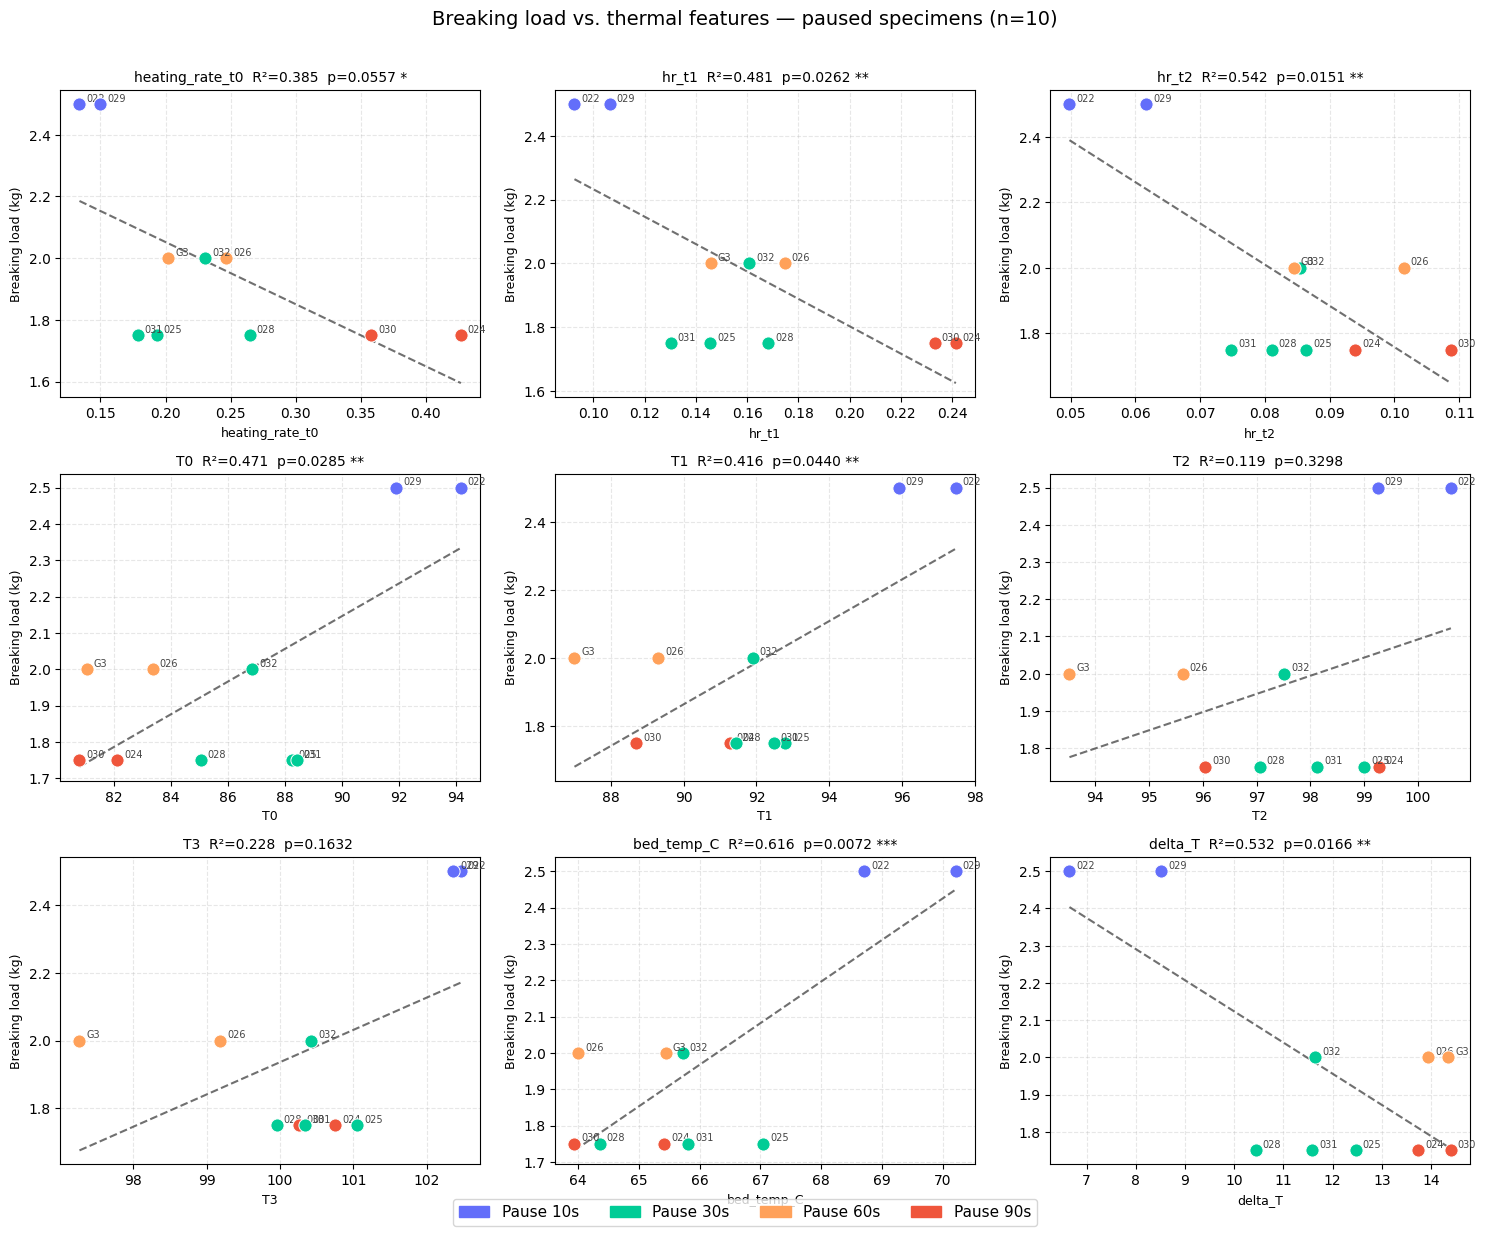

Saved: scatter_grid.png


In [3]:
GRID_FEATS = [
    "heating_rate_t0", "hr_t1", "hr_t2",
    "T0",             "T1",    "T2",
    "T3",             "bed_temp_C", "delta_T"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.patch.set_facecolor("white")
axes_flat = axes.flatten()

for i, feat in enumerate(GRID_FEATS):
    ax = axes_flat[i]
    ax.set_facecolor("white")
    if feat not in df.columns:
        ax.set_title(f"{feat} — NOT FOUND"); continue
    for _, row in df.iterrows():
        p = int(row["pausa_s"])
        ax.scatter(row[feat], row[Y], color=PAUSE_COLORS.get(p, "#888"),
                   s=90, zorder=3, edgecolors="white", linewidths=0.7)
        ax.annotate(row["specimen"].replace("Rec-","").split("_")[0],
                    (row[feat], row[Y]), textcoords="offset points",
                    xytext=(5,2), fontsize=7, color="#444")
    xv = df[feat].dropna().values
    yv = df.loc[df[feat].notna(), Y].values
    if len(xv) >= 3:
        slope, intercept, r, p_val, _ = stats.linregress(xv, yv)
        x_line = np.linspace(xv.min(), xv.max(), 100)
        ax.plot(x_line, intercept + slope*x_line, "--", color="#333", linewidth=1.5, alpha=0.7)
        sig = "***" if p_val<0.01 else ("**" if p_val<0.05 else ("*" if p_val<0.1 else ""))
        ax.set_title(f"{feat}  R²={r**2:.3f}  p={p_val:.4f} {sig}", fontsize=10)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("Breaking load (kg)", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)

fig.legend(handles=[mpatches.Patch(color=PAUSE_COLORS[p], label=f"Pause {p}s")
                    for p in [10,30,60,90]],
           loc="lower center", ncol=4, fontsize=11, bbox_to_anchor=(0.5,-0.01))
fig.suptitle("Breaking load vs. thermal features — paused specimens (n=10)",
             fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "scatter_grid.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Saved: scatter_grid.png")

## 3 · Univariate R² Ranking

OLS: `peso_rottura_kg ~ feature` for every feature.  
Dashed line = baseline R² from `pausa_s` alone.  
**Blue = direct IR measurement** (T1–T6, bed_temp_C) | **Red = WLS-fitted feature**

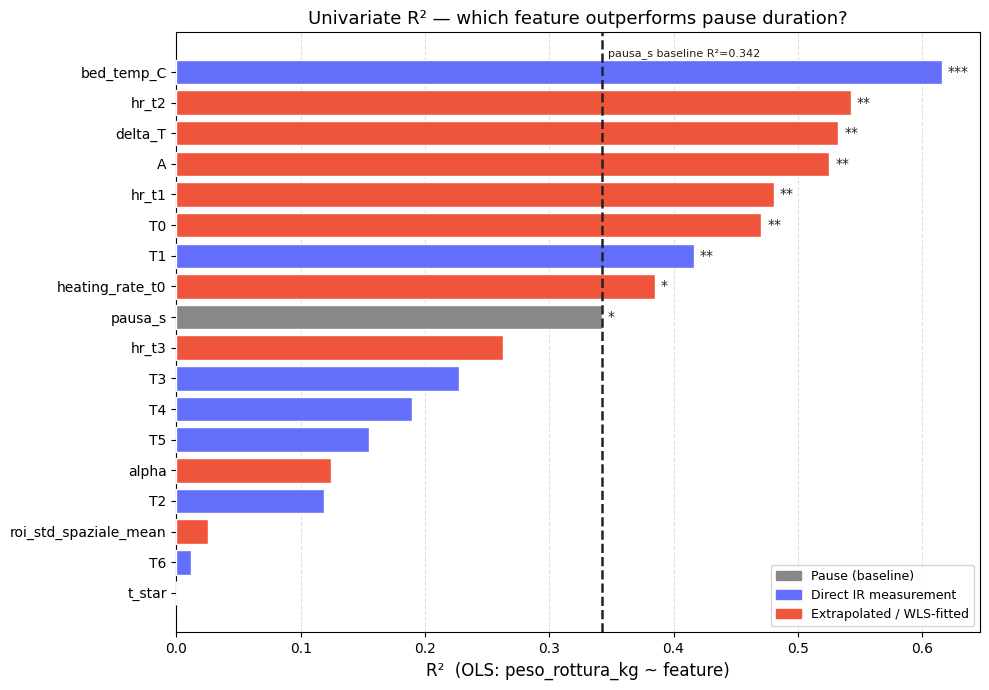

Saved: r2_ranking.png

Top features by R²:
        feature       R2  slope_p category
     bed_temp_C 0.615747 0.007184   direct
          hr_t2 0.542439 0.015126   extrap
        delta_T 0.532454 0.016600   extrap
              A 0.525033 0.017769   extrap
          hr_t1 0.480571 0.026225   extrap
             T0 0.470681 0.028487   extrap
             T1 0.416100 0.044016   direct
heating_rate_t0 0.384730 0.055719   extrap
        pausa_s 0.342074 0.075737     ctrl
          hr_t3 0.262649 0.129871   extrap


In [4]:
def ols_r2(x, y):
    mask = ~(np.isnan(x)|np.isnan(y))
    xm, ym = x[mask], y[mask]
    if len(xm) < 3: return np.nan, np.nan, np.nan, np.nan
    slope, intercept, r, p, se = stats.linregress(xm, ym)
    return r**2, intercept, slope, p

r2_results = []
for feat in ALL_FEAT:
    if feat not in df.columns: continue
    r2, _, _, p = ols_r2(df[feat].values, df[Y].values)
    if np.isnan(r2): continue
    r2_results.append({"feature": feat, "R2": r2, "slope_p": p,
                       "category": "ctrl" if feat in FEAT_CTRL
                                   else ("direct" if feat in FEAT_DIRECT else "extrap")})
df_r2 = pd.DataFrame(r2_results).sort_values("R2", ascending=False)
r2_pausa = df_r2.loc[df_r2.feature=="pausa_s", "R2"].values[0]

df_plot = df_r2.sort_values("R2", ascending=True)
colors  = [CAT_COLORS[c] for c in df_plot["category"]]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
bars = ax.barh(df_plot["feature"], df_plot["R2"], color=colors, edgecolor="white", zorder=3)
for bar, p in zip(bars, df_plot["slope_p"]):
    sig = "***" if p<0.01 else ("**" if p<0.05 else ("*" if p<0.1 else ""))
    if sig: ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                   sig, va="center", fontsize=10, color="#222")
ax.axvline(r2_pausa, color="#222", linewidth=1.8, linestyle="--", zorder=4)
ax.text(r2_pausa+0.005, len(df_plot)-0.5,
        f"pausa_s baseline R²={r2_pausa:.3f}", fontsize=8, color="#222")
ax.legend(handles=[mpatches.Patch(color=c, label=l) for c,l in
          [("#888","Pause (baseline)"),("#636EFA","Direct IR measurement"),("#EF553B","Extrapolated / WLS-fitted")]],
          fontsize=9, loc="lower right")
ax.set_xlabel("R²  (OLS: peso_rottura_kg ~ feature)", fontsize=12)
ax.set_title("Univariate R² — which feature outperforms pause duration?", fontsize=13)
ax.grid(True, axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "r2_ranking.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Saved: r2_ranking.png")

print("\nTop features by R²:")
print(df_r2[['feature','R2','slope_p','category']].head(10).to_string(index=False))

## 4 · Mediation Test (Baron & Kenny)

| Model | What it tests |
|---|---|
| `peso ~ pausa_s` | Total effect of pause (baseline R²) |
| `peso ~ X` | Direct predictive power of X |
| `peso ~ pausa_s + X` | Does pause still add information once we know X? |

**ΔR²(pausa | X)** = R²(pausa+X) − R²(X).  
If Δ ≈ 0 → knowing X makes pause redundant → **X is the physical mediator**.

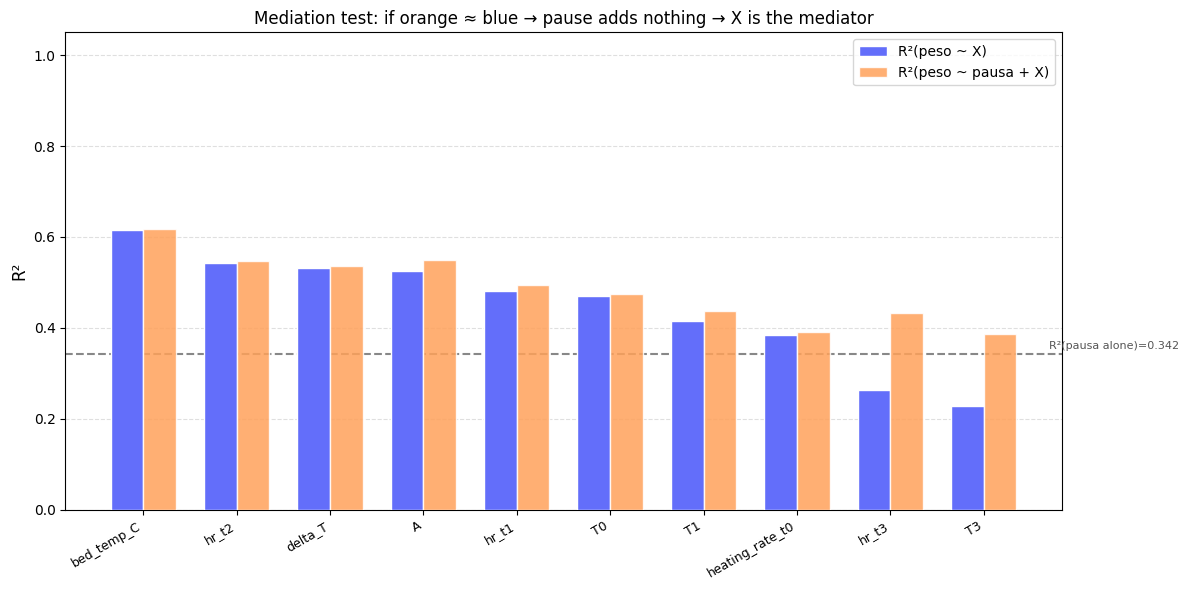

Saved: mediation_test.png

Mediation results:
              feature     R2_X  R2_pausa_X  delta_pausa  mediator category
           bed_temp_C 0.615747    0.617922     0.002176      True   direct
                hr_t2 0.542439    0.546566     0.004127      True   extrap
              delta_T 0.532454    0.535954     0.003500      True   extrap
                    A 0.525033    0.548373     0.023340      True   extrap
                hr_t1 0.480571    0.495195     0.014623      True   extrap
                   T0 0.470681    0.474413     0.003732      True   extrap
                   T1 0.416100    0.437759     0.021659      True   direct
      heating_rate_t0 0.384730    0.391702     0.006972      True   extrap
                hr_t3 0.262649    0.431927     0.169278     False   extrap
                   T3 0.227601    0.387392     0.159790     False   direct
                   T4 0.189737    0.378079     0.188343     False   direct
                   T5 0.154987    0.344187     0.18920

In [5]:
def ols_r2_multi(X_mat, y):
    mask = ~np.isnan(y)
    for col in range(X_mat.shape[1]): mask &= ~np.isnan(X_mat[:,col])
    Xm, ym = X_mat[mask], y[mask]
    if len(ym) < X_mat.shape[1]+2: return np.nan
    Xc = np.column_stack([np.ones(len(Xm)), Xm])
    coeffs, _, _, _ = np.linalg.lstsq(Xc, ym, rcond=None)
    y_hat = Xc @ coeffs
    ss_res = np.sum((ym-y_hat)**2); ss_tot = np.sum((ym-ym.mean())**2)
    return 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

y_arr     = df[Y].values
pausa_arr = df["pausa_s"].values

med_results = []
for feat in FEAT_DIRECT + FEAT_EXTRAP:
    if feat not in df.columns: continue
    r2_x, _, _, _ = ols_r2(df[feat].values, y_arr)
    if np.isnan(r2_x): continue
    r2_both = ols_r2_multi(np.column_stack([pausa_arr, df[feat].values]), y_arr)
    delta   = r2_both - r2_x if not np.isnan(r2_both) else np.nan
    mediator = (r2_x >= r2_pausa*0.9) and (not np.isnan(delta)) and (delta < 0.05)
    med_results.append({"feature": feat, "R2_X": r2_x, "R2_pausa_X": r2_both,
                        "delta_pausa": delta, "mediator": mediator,
                        "category": "direct" if feat in FEAT_DIRECT else "extrap"})
df_med = pd.DataFrame(med_results).sort_values("R2_X", ascending=False)

df_mp  = df_med.head(10)
x_pos  = np.arange(len(df_mp)); width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
ax.bar(x_pos-width/2, df_mp["R2_X"],       width, label="R²(peso ~ X)",          color="#636EFA", edgecolor="white", zorder=3)
ax.bar(x_pos+width/2, df_mp["R2_pausa_X"], width, label="R²(peso ~ pausa + X)", color="#FFA15A", edgecolor="white", zorder=3, alpha=0.85)
ax.axhline(r2_pausa, color="#888", linewidth=1.5, linestyle="--")
ax.text(len(df_mp)-0.3, r2_pausa+0.012, f"R²(pausa alone)={r2_pausa:.3f}", fontsize=8, color="#555")
ax.set_xticks(x_pos); ax.set_xticklabels(df_mp["feature"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("R²", fontsize=12)
ax.set_title("Mediation test: if orange ≈ blue → pause adds nothing → X is the mediator", fontsize=12)
ax.legend(fontsize=10); ax.set_ylim(0,1.05)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "mediation_test.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Saved: mediation_test.png")

print("\nMediation results:")
print(df_med[['feature','R2_X','R2_pausa_X','delta_pausa','mediator','category']].to_string(index=False))

## 5 · Proxy Check: Is `bed_temp_C` Just Pause in Disguise?

Although `bed_temp_C` is a **direct IR measurement**, it is measured after the pause — so it may correlate strongly with pause duration.  
We quantify how much variance in `bed_temp_C` is explained by `pausa_s` alone,
and whether within-pause variability is non-negligible (which would mean `bed_temp_C` carries extra information).

Pearson  r(bed_temp_C, pausa_s) = -0.703   p = 0.0233
Spearman ρ(bed_temp_C, pausa_s) = -0.834   p = 0.0027
R²(bed_temp_C ~ pausa_s)        = 0.494

Within-pause variability of bed_temp_C:
 pausa_s  n   mean   std    min    max  cv_%
      10  2 69.464 1.065 68.711 70.217 1.533
      30  4 65.736 1.102 64.356 67.051 1.676
      60  2 64.725 1.015 64.007 65.442 1.568
      90  2 64.679 1.042 63.943 65.416 1.610


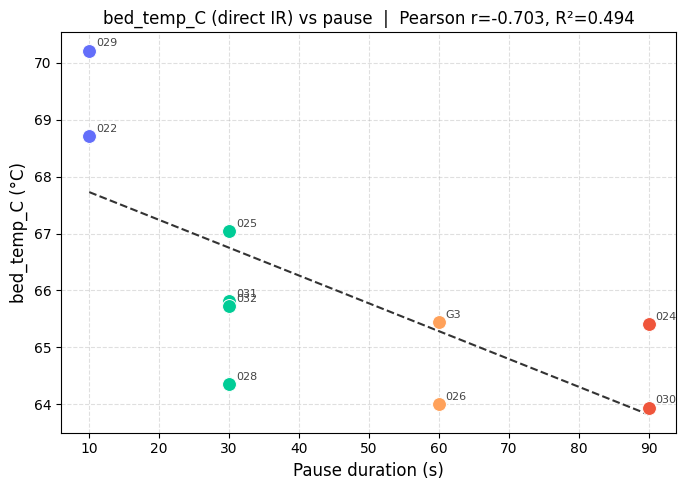

Conclusion: R² < 0.60 → bed_temp_C is substantially independent of nominal pause duration.


In [6]:
bed  = df["bed_temp_C"].values
paus = df["pausa_s"].values
r_p, p_p = pearsonr(bed, paus)
r_s, p_s = spearmanr(bed, paus)
r2_bp, _, _, _ = ols_r2(paus, bed)

print(f"Pearson  r(bed_temp_C, pausa_s) = {r_p:.3f}   p = {p_p:.4f}")
print(f"Spearman ρ(bed_temp_C, pausa_s) = {r_s:.3f}   p = {p_s:.4f}")
print(f"R²(bed_temp_C ~ pausa_s)        = {r2_bp:.3f}")
print()

intra = (df.groupby("pausa_s")
           .agg(n=("bed_temp_C","size"), mean=("bed_temp_C","mean"),
                std=("bed_temp_C","std"), min=("bed_temp_C","min"),
                max=("bed_temp_C","max")).reset_index())
intra["cv_%"] = 100 * intra["std"] / intra["mean"]
print("Within-pause variability of bed_temp_C:")
print(intra.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
for _, row in df.iterrows():
    p = int(row["pausa_s"])
    ax.scatter(row["pausa_s"], row["bed_temp_C"],
               color=PAUSE_COLORS.get(p,"#888"), s=100, edgecolors="white", linewidths=0.7, zorder=3)
    ax.annotate(row["specimen"].replace("Rec-","").split("_")[0],
                (row["pausa_s"], row["bed_temp_C"]),
                textcoords="offset points", xytext=(5,3), fontsize=8, color="#444")
slope_bp, int_bp, _, _, _ = stats.linregress(paus, bed)
xl = np.linspace(paus.min(), paus.max(), 100)
ax.plot(xl, int_bp+slope_bp*xl, "--", color="#333", linewidth=1.5)
ax.set_xlabel("Pause duration (s)", fontsize=12)
ax.set_ylabel("bed_temp_C (°C)", fontsize=12)
ax.set_title(f"bed_temp_C (direct IR) vs pause  |  Pearson r={r_p:.3f}, R²={r2_bp:.3f}", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.4); plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "bedtemp_vs_pause.png"), dpi=150, bbox_inches="tight")
plt.show()

if r2_bp > 0.90:
    print("Conclusion: R² > 0.90 → bed_temp_C is essentially a proxy for pause duration.")
elif r2_bp > 0.60:
    print("Conclusion: R² 0.60-0.90 → strong but incomplete; bed_temp_C carries extra specimen-level variance.")
else:
    print("Conclusion: R² < 0.60 → bed_temp_C is substantially independent of nominal pause duration.")

## 6 · PCA of Thermal Feature Space (paused specimens)

**Features included:** T0–T6, hr_t1, hr_t2, bed_temp_C, delta_T, A, heating_rate_t0  
**Scaling:** StandardScaler (zero mean, unit variance)  
**Point size in biplot:** proportional to breaking load

Features: ['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'hr_t1', 'hr_t2', 'bed_temp_C', 'delta_T', 'A', 'heating_rate_t0']
  PC1: 71.8%  (cumulative 71.8%)
  PC2: 18.9%  (cumulative 90.7%)
  PC3: 4.8%  (cumulative 95.5%)
  PC4: 2.2%  (cumulative 97.7%)
  PC5: 1.5%  (cumulative 99.1%)


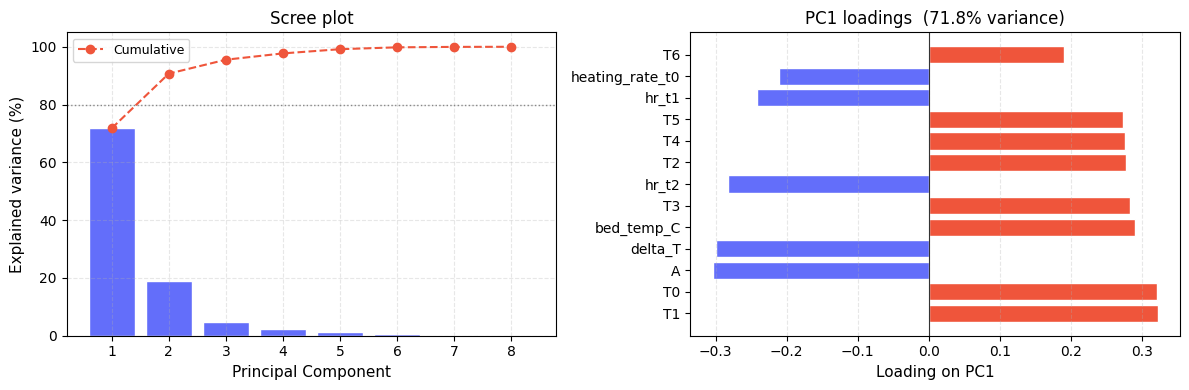

Saved: pca_scree_loadings.png


In [7]:
PCA_FEATS = [f for f in ["T0","T1","T2","T3","T4","T5","T6",
                          "hr_t1","hr_t2","bed_temp_C","delta_T",
                          "A","heating_rate_t0"] if f in df.columns]

df_pca = df[PCA_FEATS + [Y, "pausa_s", "specimen"]].dropna()
X_sc   = StandardScaler().fit_transform(df_pca[PCA_FEATS].values)
pca    = PCA(n_components=min(len(PCA_FEATS), len(df_pca)))
scores = pca.fit_transform(X_sc)
loadings  = pca.components_
explained = pca.explained_variance_ratio_ * 100

print(f"Features: {PCA_FEATS}")
for i, ev in enumerate(explained[:5]):
    print(f"  PC{i+1}: {ev:.1f}%  (cumulative {explained[:i+1].sum():.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4)); fig.patch.set_facecolor("white")
ax = axes[0]; ax.set_facecolor("white")
n_show = min(8, len(explained))
ax.bar(range(1,n_show+1), explained[:n_show], color="#636EFA", edgecolor="white")
ax.plot(range(1,n_show+1), np.cumsum(explained[:n_show]), "o--", color="#EF553B", label="Cumulative")
ax.axhline(80, color="#888", linestyle=":", linewidth=1)
ax.set_xlabel("Principal Component", fontsize=11); ax.set_ylabel("Explained variance (%)", fontsize=11)
ax.set_title("Scree plot", fontsize=12); ax.legend(fontsize=9); ax.grid(True, linestyle="--", alpha=0.3)
ax2 = axes[1]; ax2.set_facecolor("white")
sort_idx = np.argsort(np.abs(loadings[0]))[::-1]
load_colors = ["#EF553B" if loadings[0][j]>=0 else "#636EFA" for j in sort_idx]
ax2.barh([PCA_FEATS[j] for j in sort_idx], loadings[0][sort_idx], color=load_colors, edgecolor="white")
ax2.axvline(0, color="#333", linewidth=0.8)
ax2.set_xlabel("Loading on PC1", fontsize=11)
ax2.set_title(f"PC1 loadings  ({explained[0]:.1f}% variance)", fontsize=12)
ax2.grid(True, axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "pca_scree_loadings.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Saved: pca_scree_loadings.png")

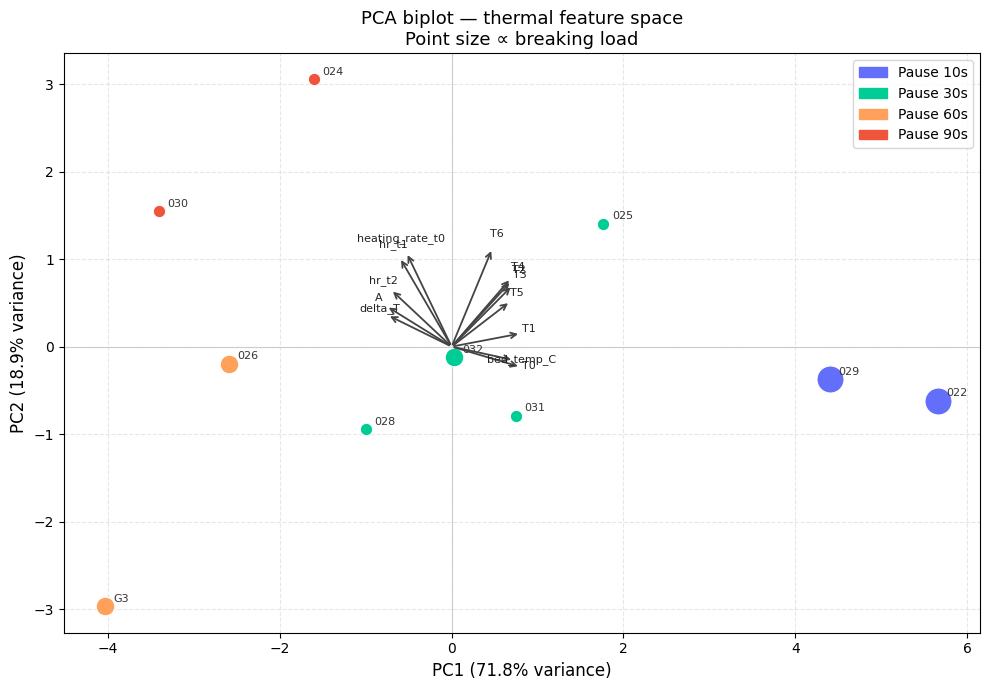

Saved: pca_biplot.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
peso  = df_pca[Y].values
sizes = 80 + 300*(peso-peso.min())/(peso.max()-peso.min()+1e-9)
for idx, (_, row) in enumerate(df_pca.iterrows()):
    p = int(row["pausa_s"])
    ax.scatter(scores[idx,0], scores[idx,1],
               color=PAUSE_COLORS.get(p,"#888"), s=sizes[idx],
               zorder=3, edgecolors="white", linewidths=0.8)
    ax.annotate(row["specimen"].replace("Rec-","").split("_")[0],
                (scores[idx,0], scores[idx,1]),
                textcoords="offset points", xytext=(6,3), fontsize=8, color="#333")
scale = 2.5
for j, feat in enumerate(PCA_FEATS):
    ax.annotate("", xy=(loadings[0,j]*scale, loadings[1,j]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color="#444", lw=1.3))
    ax.text(loadings[0,j]*scale*1.12, loadings[1,j]*scale*1.12,
            feat, fontsize=8, color="#222", ha="center")
ax.axhline(0, color="#ccc", lw=0.8); ax.axvline(0, color="#ccc", lw=0.8)
ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance)", fontsize=12)
ax.set_title("PCA biplot — thermal feature space\nPoint size ∝ breaking load", fontsize=13)
ax.legend(handles=[mpatches.Patch(color=PAUSE_COLORS[p], label=f"Pause {p}s")
                   for p in [10,30,60,90]], fontsize=10, loc="upper right")
ax.grid(True, linestyle="--", alpha=0.3); plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "pca_biplot.png"), dpi=150, bbox_inches="tight")
plt.show(); print("Saved: pca_biplot.png")

In [9]:
print("Correlation of PC scores with peso_rottura_kg:")
print(f"{'PC':<6} {'Pearson r':>10} {'p-value':>10}")
print("-"*30)
for i in range(min(5, scores.shape[1])):
    r, p = pearsonr(scores[:,i], df_pca[Y].values)
    sig = "***" if p<0.01 else ("**" if p<0.05 else ("*" if p<0.1 else ""))
    print(f"PC{i+1:<5} {r:>10.3f} {p:>10.4f}  {sig}")

Correlation of PC scores with peso_rottura_kg:
PC      Pearson r    p-value
------------------------------
PC1          0.681     0.0302  **
PC2         -0.351     0.3197  
PC3         -0.071     0.8444  
PC4          0.200     0.5797  
PC5          0.340     0.3371  


## 7 · PCA with STD Specimens Projected onto Paused-only Space

### Why this matters
The PCA in Section 6 was **fit exclusively on paused specimens** (n=10).  
STD specimens (no pause, continuous printing) are **not used to fit the PCA axes** — they are projected
as out-of-sample points using the same scaler and rotation matrix.

This is the correct approach because:
- STD specimens have a fundamentally different thermal regime (no cooling cycle).
- Including them in the fit would distort the axes and mask the variance structure of paused specimens.
- Projecting them *after* fitting lets us ask: **where do STD specimens fall in the paused-specimen thermal space?**

### Expected interpretation
Since STD specimens have no pause, their bed is always hotter (no cooling → high T values, high PC1).  
They should appear at the **far positive end of PC1** — confirming that PC1 is an axis of "thermal level" (hotter = more positive).  
Their PC2 position reveals whether they share the same heating dynamics as any paused group or are structurally different.

In [10]:
# ── 7a. Fit scaler + PCA on paused specimens only (reuse from Sec 6) ──
scaler_std = StandardScaler()
X_paused   = scaler_std.fit_transform(df_pca[PCA_FEATS].values)
pca_std    = PCA(n_components=min(len(PCA_FEATS), len(df_pca)))
scores_paused = pca_std.fit_transform(X_paused)
loadings_std  = pca_std.components_
explained_std = pca_std.explained_variance_ratio_ * 100

# ── 7b. Project STD specimens onto the same axes ──
df_std_pca = df_std[PCA_FEATS + ["specimen"]].copy()
df_std_pca = df_std_pca.dropna(subset=PCA_FEATS)

if len(df_std_pca) == 0:
    print("WARNING: No STD specimens found after dropna. Check that PCA_FEATS columns exist in df_std.")
    print(f"Available STD columns: {list(df_std.columns)}")
else:
    X_std_scaled  = scaler_std.transform(df_std_pca[PCA_FEATS].values)
    scores_std    = pca_std.transform(X_std_scaled)
    print(f"Projected {len(df_std_pca)} STD specimen(s) onto paused PCA space")
    for i, (_, row) in enumerate(df_std_pca.iterrows()):
        print(f"  {row['specimen']}: PC1={scores_std[i,0]:.2f}, PC2={scores_std[i,1]:.2f}")

Available STD columns: ['specimen', 'pausa_s', 'peso_rottura_kg', 'n_layers', 'T0', 'A', 'alpha', 'T_inf', 't_star', 'heating_rate_t0', 'hr_t1', 'hr_t2', 'hr_t3', 'hr_t4', 'hr_t5', 'hr_t6', 'delta_T', 'sigma_T0', 'sigma_A', 'sigma_alpha', 'fit_ok', 'roi_std_spaziale_mean', 'roi_skew_spaziale_mean', 'bed_temp_C', 'bed_temp_std_C', 'T0.1', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']


AttributeError: 'str' object has no attribute 'items'

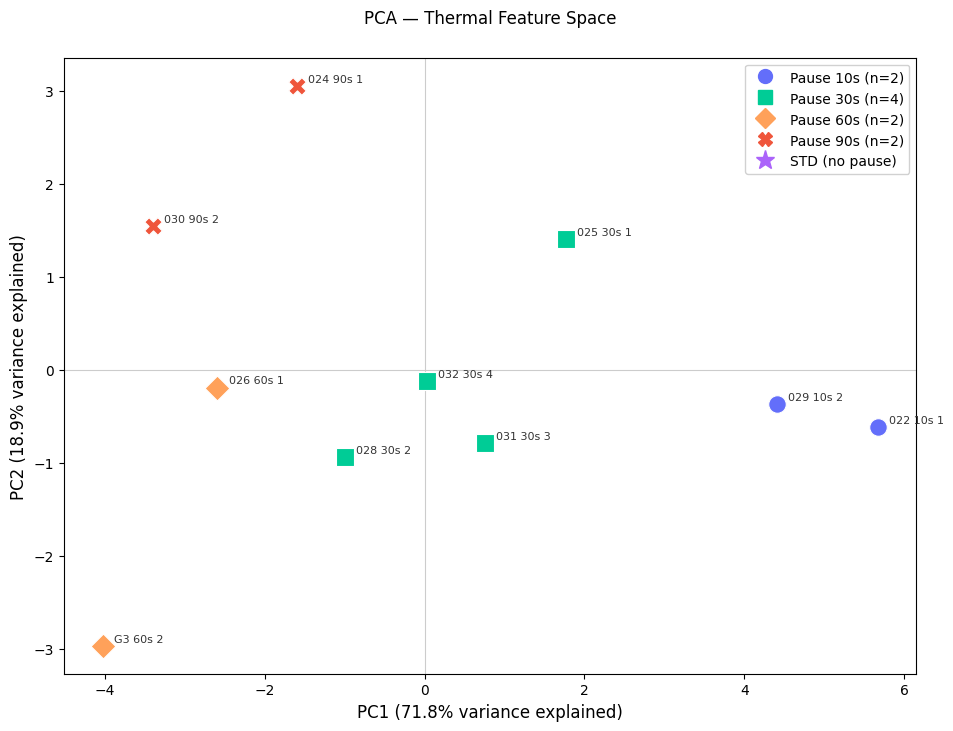

In [11]:
# ── 7c. Plot: paused specimens + STD projected ──
PAUSE_MARKERS = {10: "o", 30: "s", 60: "D", 90: "X"}
STD_COLOR     = "#AB63FA"

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")

# --- Paused specimens ---
for idx, (_, row) in enumerate(df_pca.iterrows()):
    p   = int(row["pausa_s"])
    col = PAUSE_COLORS.get(p, "#888")
    mrk = PAUSE_MARKERS.get(p, "o")
    ax.scatter(scores_paused[idx,0], scores_paused[idx,1],
               color=col, marker=mrk, s=160, zorder=4,
               edgecolors="white", linewidths=0.8)
    label = row["specimen"].replace("Rec-","")
    # add pause group label: e.g. '022 10s 1'
    short = label.split("_")[0]
    ax.annotate(f"{short} {p}s {df_pca.groupby('pausa_s').cumcount().iloc[idx]+1}",
                (scores_paused[idx,0], scores_paused[idx,1]),
                textcoords="offset points", xytext=(8,3), fontsize=8, color="#333")

# --- STD specimens projected ---
if len(df_std_pca) > 0:
    for i, (_, row) in enumerate(df_std_pca.iterrows()):
        ax.scatter(scores_std[i,0], scores_std[i,1],
                   color=STD_COLOR, marker="*", s=400, zorder=5,
                   edgecolors="white", linewidths=0.8)
        short = row["specimen"].replace("Rec-","").split("_")[0]
        ax.annotate(f"{short} std {i+1}",
                    (scores_std[i,0], scores_std[i,1]),
                    textcoords="offset points", xytext=(8,3), fontsize=8,
                    color=STD_COLOR, fontweight="bold")

ax.axhline(0, color="#ccc", lw=0.8, zorder=1)
ax.axvline(0, color="#ccc", lw=0.8, zorder=1)

# Legend
legend_handles = []
for p_val, cnt in df_pca.groupby('pausa_s').size().items():
    h = mlines.Line2D([], [], color=PAUSE_COLORS[int(p_val)],
                      marker=PAUSE_MARKERS[int(p_val)], linestyle='None',
                      markersize=10, label=f"Pause {int(p_val)}s (n={cnt})")
    legend_handles.append(h)
legend_handles.append(
    mlines.Line2D([], [], color=STD_COLOR, marker="*", linestyle='None',
                  markersize=14, label="STD (no pause)")
)
ax.legend(handles=legend_handles, fontsize=10, loc="upper right",
          framealpha=0.9, edgecolor="#ccc")

ax.set_xlabel(f"PC1 ({explained_std[0]:.1f}% variance explained)", fontsize=12)
ax.set_ylabel(f"PC2 ({explained_std[1]:.1f}% variance explained)", fontsize=12)
ax.set_title(
    f"PCA — Thermal Feature Space\n",
    f"PC1={explained_std[0]:.0f}%, PC2={explained_std[1]:.0f}%  |  STD projected onto paused-only PCA",
    fontsize=13, pad=10
)
ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "pca_thermal_feature_space.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_thermal_feature_space.png")

## Summary

| Step | Key finding |
|---|---|
| Scatter grid | Visual check of linearity and pause-group separation for 9 features |
| R² ranking | Identifies features that outperform pause duration as univariate predictors |
| Mediation test | Features with Δ ≈ 0 fully replace pause as predictor — physical mediators |
| Proxy check | Quantifies how much of `bed_temp_C` is explained by pause alone |
| PCA (paused) | Low-dimensional structure of the thermal feature space, linked to breaking load |
| PCA + STD projection | STD specimens land at extreme positive PC1 → confirm PC1 = thermal level axis |

> **Note:** n=10 paused + 2 STD. All results are exploratory. Relative rankings are informative; absolute R² values should be interpreted with caution.